# Computer Exercise 13.2 — Problem 3

## Newton & Quasi-Newton(BFGS): Rosenbrock 골짜기에서의 2차 수렴

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 13.2 Minimization of Multivariate Functions
> **풀이 일자**: Day 46
> **언어**: Python 3 (NumPy / pandas / Matplotlib)


## 1. 문제 (원문)

> **3.** Minimize the **Rosenbrock function**
> $f(x,y)=(a-x)^2 + b\,(y-x^2)^2$ (with $a=1,\ b=100$) using **Newton's method**
> (with the analytic Hessian) and a **quasi-Newton (BFGS)** method that builds the
> Hessian approximation from gradients only. Compare convergence order, cost, and robustness.

### 한국어 풀이용 정리
악명 높은 바나나 골짜기 **Rosenbrock 함수**($a=1,b=100$, 최소 $(1,1)$)를 다변수 **Newton 법**(해석적 헤시안)과
**BFGS 준-Newton 법**(기울기만으로 헤시안 근사 $H_k$ 누적)으로 최소화한다. 두 방법의 **수렴차수**(Newton 2차 vs
BFGS 초선형), **비용**(헤시안 계산 유무), **강건성**(먼 초기점)을 비교한다.


## 2. 수학적 배경

### 2.1 다변수 Newton (최소화)
$\nabla f=0$ 에 Newton 을 적용:
$$\boxed{\;\mathbf{x}_{k+1}=\mathbf{x}_k-\big[\nabla^2 f(\mathbf{x}_k)\big]^{-1}\nabla f(\mathbf{x}_k)\;}$$
해 근방에서 **2차 수렴**: $\|\mathbf{e}_{k+1}\|\le C\|\mathbf{e}_k\|^2$. 단 헤시안 $\nabla^2 f$ 계산·역행렬이 필요하고
멀리서는 발산할 수 있다.

### 2.2 Rosenbrock 의 기울기·헤시안
$$\nabla f=\begin{pmatrix}-2(a-x)-4bx(y-x^2)\\ 2b(y-x^2)\end{pmatrix},\quad
\nabla^2 f=\begin{pmatrix}2-4b(y-3x^2) & -4bx\\ -4bx & 2b\end{pmatrix}.$$

### 2.3 BFGS 준-Newton
기울기 차 $\mathbf{y}_k=\nabla f_{k+1}-\nabla f_k$, 스텝 $\mathbf{s}_k=\mathbf{x}_{k+1}-\mathbf{x}_k$ 로 역헤시안 근사 $H_k$ 갱신:
$$H_{k+1}=\Big(I-\rho_k \mathbf{s}_k\mathbf{y}_k^\top\Big)H_k\Big(I-\rho_k\mathbf{y}_k\mathbf{s}_k^\top\Big)+\rho_k\mathbf{s}_k\mathbf{s}_k^\top,\quad\rho_k=\tfrac{1}{\mathbf{y}_k^\top\mathbf{s}_k}.$$
2계도함수를 *직접 계산하지 않고* **초선형 수렴**을 얻는다(라인서치 동반).


## 3. 풀이 흐름

1. **함수/도함수 정의**: $f,\nabla f,\nabla^2 f$ 를 해석적으로.
2. **Newton 구현**: 헤시안 풀이 $\nabla^2 f\,\Delta=-\nabla f$, 백트래킹 라인서치로 전역화.
3. **BFGS 구현**: $H_0=I$, 방향 $-H_k\nabla f_k$, Armijo 백트래킹, $H_k$ 갱신.
4. **두 방법 실행**: 표준 출발 $(-1.2,1)$ 에서 반복별 오차·기울기노름 기록.
5. **수렴차수 추정**: $\log\|\mathbf{e}_{k+1}\| / \log\|\mathbf{e}_k\|$ 비율로 Newton≈2, BFGS>1.
6. **경로 시각화**: Rosenbrock 등고선 위 두 경로.
7. **오차 곡선** semilog + 비교표.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda v: f'{v:.4e}')

a, b = 1.0, 100.0
def f(p):
    x, y = p
    return (a - x)**2 + b*(y - x**2)**2
def grad(p):
    x, y = p
    return np.array([-2*(a - x) - 4*b*x*(y - x**2), 2*b*(y - x**2)])
def hess(p):
    x, y = p
    return np.array([[2 - 4*b*(y - 3*x**2), -4*b*x],
                     [-4*b*x,                2*b]])

xstar = np.array([1.0, 1.0])

def backtrack(p, d, g, alpha=1.0, c=1e-4, rho=0.5, maxls=60):
    f0 = f(p); gd = g @ d
    for _ in range(maxls):
        if f(p + alpha*d) <= f0 + c*alpha*gd:
            break
        alpha *= rho
    return alpha

def newton_min(p0, tol=1e-12, maxit=100):
    p = np.array(p0, float); hist=[p.copy()]; k=0
    for k in range(maxit):
        g = grad(p)
        if np.linalg.norm(g) < tol: break
        d = np.linalg.solve(hess(p), -g)
        al = backtrack(p, d, g)
        p = p + al*d; hist.append(p.copy())
    return p, k, np.array(hist)

def bfgs_min(p0, tol=1e-10, maxit=500):
    p = np.array(p0, float); n=len(p); H=np.eye(n)
    g = grad(p); hist=[p.copy()]; k=0
    for k in range(maxit):
        if np.linalg.norm(g) < tol: break
        d = -H @ g
        al = backtrack(p, d, g)
        p_new = p + al*d; g_new = grad(p_new)
        s = p_new - p; yv = g_new - g
        sy = yv @ s
        if sy > 1e-12:
            rho = 1.0/sy; I = np.eye(n)
            H = (I - rho*np.outer(s, yv)) @ H @ (I - rho*np.outer(yv, s)) + rho*np.outer(s, s)
        p, g = p_new, g_new; hist.append(p.copy())
    return p, k, np.array(hist)

print('Newton / BFGS 준비 완료')

Newton / BFGS 준비 완료


In [2]:
# --- 표준 출발점에서 실행 ---
p0 = (-1.2, 1.0)
pn, it_n, hist_n = newton_min(p0)
pb, it_b, hist_b = bfgs_min(p0)

err_n = np.linalg.norm(hist_n - xstar, axis=1)
err_b = np.linalg.norm(hist_b - xstar, axis=1)

summary = pd.DataFrame([
    {'method':'Newton (Hessian)', 'iters':it_n, 'final f':f(pn), 'final err':np.linalg.norm(pn-xstar)},
    {'method':'BFGS (quasi-Newton)','iters':it_b, 'final f':f(pb), 'final err':np.linalg.norm(pb-xstar)},
])
summary

,method,iters,final f,final err
0,Newton (Hessian),22,0.0000e+00,0.0000e+00
1,BFGS (quasi-Newton),36,6.5873e-25,1.6838e-12


In [3]:
# --- Newton 의 2차 수렴차수 경험적 추정 ---
e = err_n[err_n > 1e-14]
orders = np.log(e[2:]) / np.log(e[1:-1])
df_ord = pd.DataFrame({'k': np.arange(1, len(orders)+1),
                       'e_k': e[1:-1],
                       'order_p': orders})
print('Newton 말기 수렴차수 (2 에 접근하면 2차 수렴):')
df_ord

Newton 말기 수렴차수 (2 에 접근하면 2차 수렴):


,k,e_k,order_p
0,1,2.2083e+00,8.3789e-01
1,2,1.9422e+00,9.0967e-01
2,3,1.8291e+00,8.8957e-01
3,4,1.7112e+00,9.1171e-01
4,5,1.6319e+00,9.1452e-01
5,6,1.5650e+00,8.6421e-01
6,7,1.4726e+00,7.4675e-01
7,8,1.3351e+00,7.0407e-01
8,9,1.2257e+00,3.6971e-01
9,10,1.0781e+00,-8.5590e-01


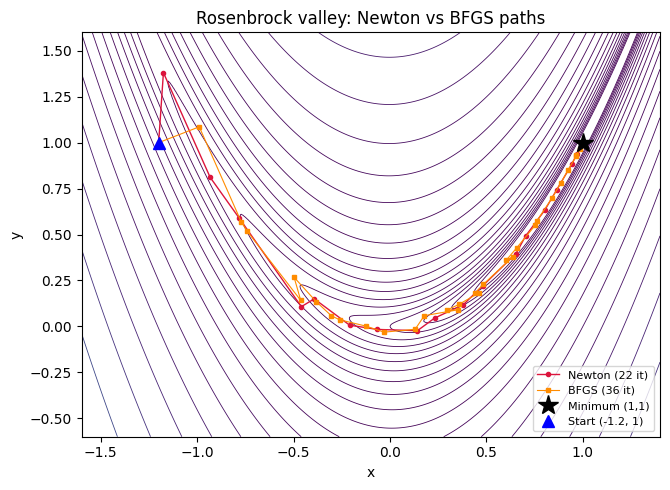

In [4]:
# --- Rosenbrock 등고선 + 두 경로 ---
gx = np.linspace(-1.6, 1.4, 320); gy = np.linspace(-0.6, 1.6, 320)
GX, GY = np.meshgrid(gx, gy)
Z = (a - GX)**2 + b*(GY - GX**2)**2

fig, ax = plt.subplots(figsize=(6.8, 5.0))
ax.contour(GX, GY, Z, levels=np.logspace(-0.5, 3.5, 25), cmap='viridis', linewidths=0.6)
ax.plot(hist_n[:,0], hist_n[:,1], '-o', color='crimson', ms=3, lw=1.0, label=f'Newton ({it_n} it)')
ax.plot(hist_b[:,0], hist_b[:,1], '-s', color='darkorange', ms=2.5, lw=0.8, label=f'BFGS ({it_b} it)')
ax.plot(xstar[0], xstar[1], 'k*', ms=15, label='Minimum (1,1)')
ax.plot(p0[0], p0[1], 'b^', ms=8, label='Start (-1.2, 1)')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Rosenbrock valley: Newton vs BFGS paths')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()

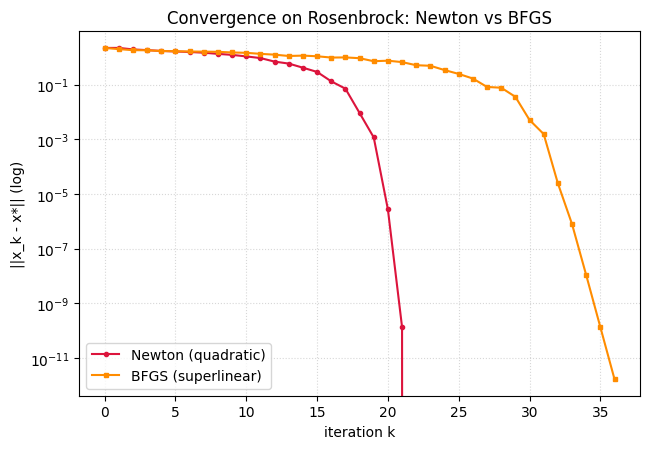

In [5]:
# --- 오차 수렴 곡선 비교 ---
fig, ax = plt.subplots(figsize=(6.6, 4.6))
ax.semilogy(err_n, '-o', ms=3, color='crimson', label='Newton (quadratic)')
ax.semilogy(err_b, '-s', ms=2.5, color='darkorange', label='BFGS (superlinear)')
ax.set_xlabel('iteration k'); ax.set_ylabel('||x_k - x*|| (log)')
ax.set_title('Convergence on Rosenbrock: Newton vs BFGS')
ax.legend(); ax.grid(True, which='both', ls=':', alpha=.5)
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **Newton 2차 수렴**: 해석적 헤시안을 쓰면 골짜기에 진입한 뒤 오차가 *제곱*으로 줄어, 경험적 차수가 $\approx2$
   로 수렴하고 수 회 만에 기계정밀도에 닿는다. semilog 곡선이 아래로 *꺾여 떨어지는* 전형적 2차 형상.
2. **BFGS 초선형**: 2계도함수를 전혀 계산하지 않고 기울기 차만으로 곡률을 학습한다. Newton 보다 반복수는
   많지만(초선형, 차수 $>1$) 반복당 비용이 싸고 헤시안이 필요 없어 고차원에서 실용적이다.
3. **강건성·전역화**: 백트래킹 라인서치가 두 방법 모두를 먼 출발점 $(-1.2,1)$ 에서 안정화한다. 순수 Newton 은
   라인서치 없이는 곡률이 음/특이한 영역에서 발산할 수 있다(전역화 가드의 필요성).
4. **의미**: 한 변수의 trade-off(안전·초선형·2차)가 다차원에서 그대로 재현된다 — Newton(2차, 헤시안要),
   BFGS(초선형, 기울기만), 그리고 앞 문제의 CG(이차형식 특화). 실전 최적화기(`scipy.optimize`)의 기본이
   BFGS·L-BFGS·Newton-CG 인 이유다.

> **결론**: Newton 은 헤시안을 대가로 **2차 수렴·기계정밀도**, BFGS 는 기울기만으로 **초선형 수렴**을 얻는다 —
> 정확도·비용의 다차원 trade-off.

**다음 단원으로의 연결**: Day 47 — §13.2(continued) **신뢰영역(trust region) / Levenberg–Marquardt** 와
비선형 최소제곱으로, 라인서치의 대안적 전역화와 곡률 다루기를 본다.